In [1]:
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

import scarf

scarf.configure_output(level="WARNING", progress=False)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(f"{dataset}/data.zarr", nthreads=4)
baseline = ds.pipeline.open(label="docs_default")
normalized = baseline["normalized"]
umap = baseline["umap"]

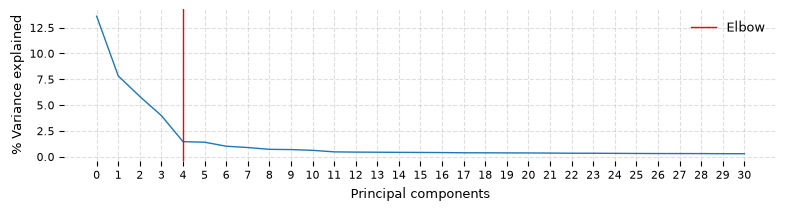

In [2]:
dimension_counts = (10, 15, 30)
pca_refs = {15: baseline["pca"]}
graph_15 = baseline["connectivity_map"]
cluster_refs = {15: baseline["leiden_0.5"]}
for dimensions in (10, 30):
    pca = ds.run_pca(
        normalized,
        dims=dimensions,
        show_elbow_plot=dimensions == 30,
    )
    pca_refs[dimensions] = pca
    ann = ds.build_ann_index(pca)
    neighbors = ds.query_neighbors(ann, k=11)
    graph = ds.build_connectivity_map(neighbors)
    cluster_refs[dimensions] = ds.run_leiden_clustering(
        graph,
        resolution=0.5,
    )

initialization_15 = baseline["embedding_initialization"]
cluster_values = {
    dimensions: np.asarray(ds.load_artifact(cluster_refs[dimensions])["values"][:])
    for dimensions in dimension_counts
}

In [3]:
scores_30 = np.asarray(ds.load_artifact(pca_refs[30])["data"])
retained_share = scores_30.var(axis=0, ddof=1)
retained_share = 100.0 * retained_share / retained_share.sum()
cumulative_share = np.cumsum(retained_share)
pd.Series(
    {
        dimensions: float(cumulative_share[dimensions - 1])
        for dimensions in dimension_counts
    },
    name="cumulative_share_of_30pc_fit",
).rename_axis("pca_dimensions")

pca_dimensions
10     83.052933
15     88.397957
30    100.000008
Name: cumulative_share_of_30pc_fit, dtype: float64

In [4]:
pd.Series(
    {
        dimensions: pd.Series(cluster_values[dimensions]).nunique()
        for dimensions in dimension_counts
    },
    name="n_clusters",
).rename_axis("pca_dimensions")

pca_dimensions
10    12
15    10
30    12
Name: n_clusters, dtype: int64

In [5]:
pd.DataFrame(
    {
        dimensions: pd.Series(cluster_values[dimensions]).value_counts()
        for dimensions in dimension_counts
    }
).fillna(0).astype(int)

,10,15,30
1,572,716,704
2,157,25,237
3,248,239,1315
4,619,1241,317
5,287,434,295
6,665,319,144
7,659,552,258
8,320,151,609
9,149,256,17
10,245,15,25


In [6]:
agreement_rows = []
for first, second in combinations(dimension_counts, 2):
    agreement_rows.append(
        {
            "comparison": f"{first} vs {second} dimensions",
            "ARI": adjusted_rand_score(cluster_values[first], cluster_values[second]),
            "NMI": normalized_mutual_info_score(
                cluster_values[first],
                cluster_values[second],
            ),
        }
    )
pd.DataFrame(agreement_rows)

,comparison,ARI,NMI
0,10 vs 15 dimensions,0.636799,0.819824
1,10 vs 30 dimensions,0.652961,0.811739
2,15 vs 30 dimensions,0.832587,0.872685


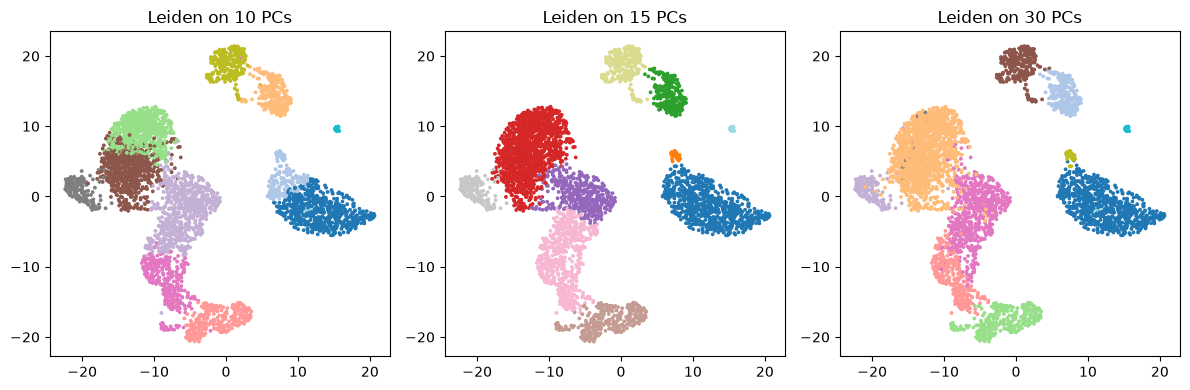

In [7]:
umap_values = np.asarray(ds.load_artifact(umap)["values"][:])
figure, axes = plt.subplots(1, 3, figsize=(12, 4))
for axis, dimensions in zip(
    axes,
    dimension_counts,
    strict=True,
):
    axis.scatter(
        umap_values[:, 0],
        umap_values[:, 1],
        c=cluster_values[dimensions],
        s=3,
        cmap="tab20",
    )
    axis.set_title(f"Leiden on {dimensions} PCs")
figure.tight_layout()
figure

In [8]:
umap_tight = ds.run_umap(graph_15, initialization_15, min_dist=0.1)

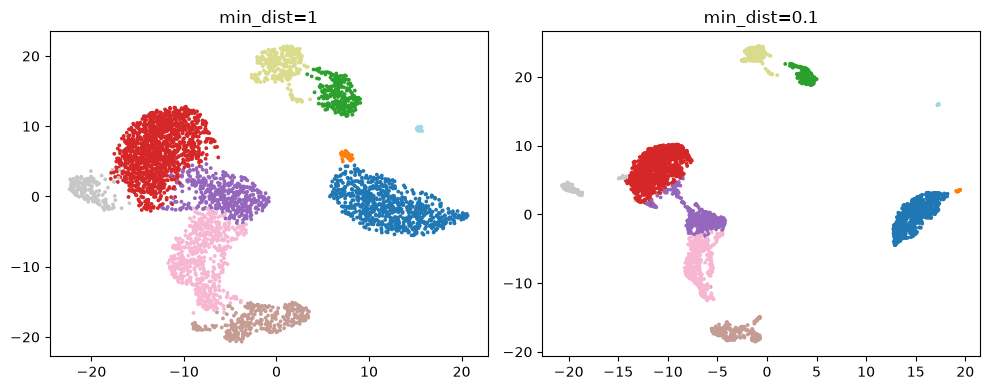

In [9]:
umap_tight_values = np.asarray(ds.load_artifact(umap_tight)["values"][:])
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
for axis, coordinates, title in zip(
    axes,
    (umap_values, umap_tight_values),
    ("min_dist=1", "min_dist=0.1"),
    strict=True,
):
    axis.scatter(
        coordinates[:, 0],
        coordinates[:, 1],
        c=cluster_values[15],
        s=3,
        cmap="tab20",
    )
    axis.set_title(title)
figure.tight_layout()
figure

In [10]:
densmap = ds.run_umap(graph_15, initialization_15, use_density_map=True)

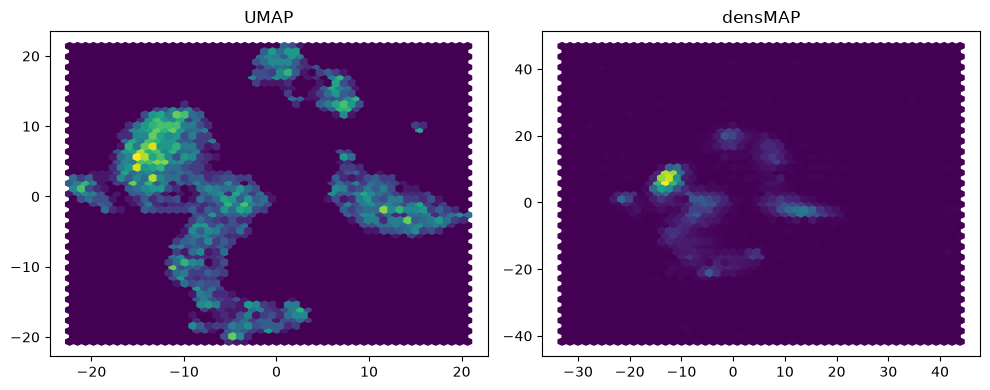

In [11]:
dense_values = np.asarray(ds.load_artifact(densmap)["values"][:])
figure, axes = plt.subplots(1, 2, figsize=(10, 4))
for axis, coordinates, title in zip(
    axes,
    (umap_values, dense_values),
    ("UMAP", "densMAP"),
    strict=True,
):
    axis.hexbin(coordinates[:, 0], coordinates[:, 1], gridsize=50)
    axis.set_title(title)
figure.tight_layout()
figure

In [12]:
tsne = ds.run_tsne(graph_15, initialization_15, verbose=False)

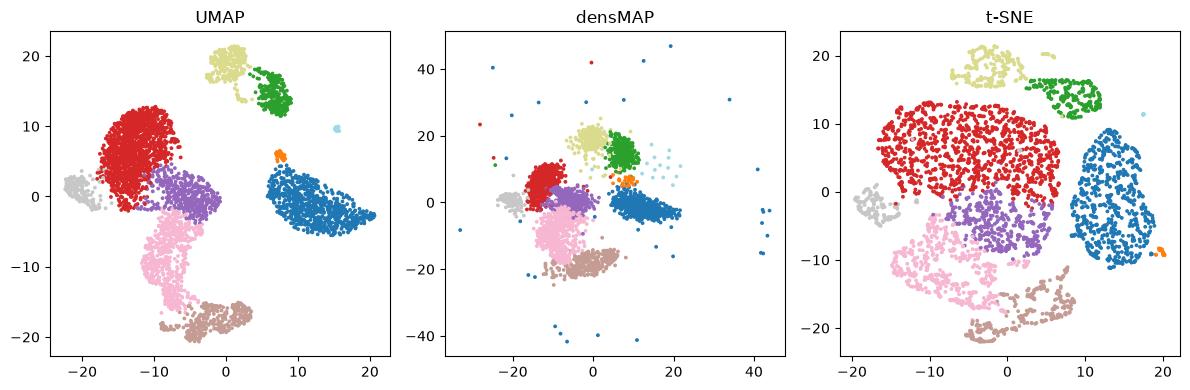

In [13]:
figure, axes = plt.subplots(1, 3, figsize=(12, 4))
tsne_values = np.asarray(ds.load_artifact(tsne)["values"][:])
layout_comparisons = (
    ("UMAP", umap_values),
    ("densMAP", dense_values),
    ("t-SNE", tsne_values),
)
for axis, (title, coordinates) in zip(
    axes,
    layout_comparisons,
    strict=True,
):
    axis.scatter(
        coordinates[:, 0],
        coordinates[:, 1],
        c=cluster_values[15],
        s=3,
        cmap="tab20",
    )
    axis.set_title(title)
figure.tight_layout()
figure